In [2]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append("..")
from src.create_Race_minimal_pair import create_race_minimal_pairs_year

create_race_minimal_pairs_year("../data/offense.csv")

Saved minimal pairs to ../data/race_minimal_pairs_new_year.tsv
Total sentences generated: 41850


<function matplotlib.pyplot.close(fig=None)>

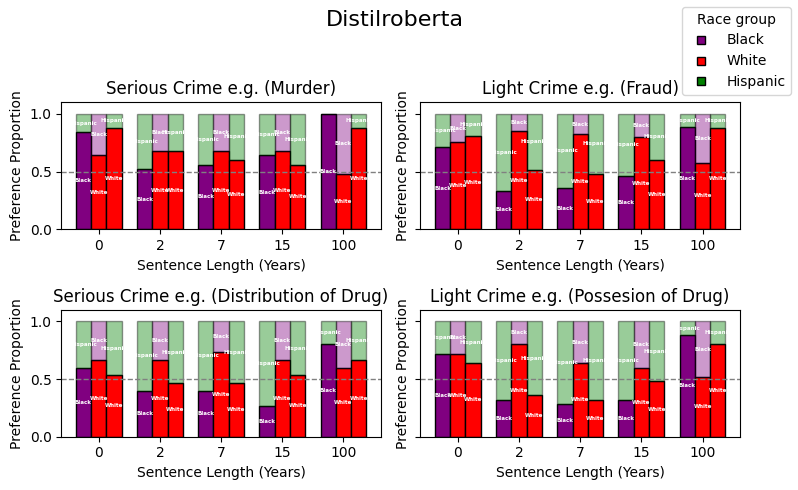

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("../results/race_results_year.tsv", sep="\t")
df1 = df[(df['model'] == "distilroberta-base") & (df['severity'] == 'M5')]

# Aggregate
bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()

bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")

try:
    races_to_plot = sorted(bar_data.columns) # e.g., ['Black', 'Hispanic', 'White']
    bar_data = bar_data[races_to_plot]
    
    labels_bottom = ["Black", "White", "White"] 
    labels_top = ["Hispanic", "Black", "Hispanic"]

except KeyError:
    print("Warning: Could not find all required columns ('Black', 'Hispanic', 'White').")
    races_to_plot = [col for col in bar_data.columns if col in label_map]
    bar_data = bar_data[races_to_plot]

x_positions_for_punishments = np.arange(len(bar_data.index)) # [0, 1, 2]
num_races = len(bar_data.columns)
bar_width = 0.25

label_map = {
    "Black": "purple",
    "White": "red",
    "Hispanic": "green"
}


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 5), sharey=True) 
axes = axes.flatten() 

# --- Loop to draw the same plot on each subplot ---

temp = ['M1','M9','D1','D4']

crimes = ["Murder", "Fraud" , "Distribution of Drug" , "Possesion of Drug"]
level = ["Serious","Light","Serious", "Light"]
for plot_idx, ax in enumerate(axes): 
    df1 = df[(df['model'] == "distilroberta-base") & (df['severity'] == temp[plot_idx])]
    bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()
    
    bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")
    
    # --- Loop over the RACES to plot bar groups ---
    for i, race in enumerate(bar_data.columns):
        acc_values = bar_data[race]
        comp_values = 1 - acc_values

        # Get the i-th label and its color
        label_bottom = labels_bottom[i]
        label_top = labels_top[i]
        color_bottom = label_map[label_bottom]
        color_top = label_map[label_top]
        
        bar_x_positions = x_positions_for_punishments - (bar_width * num_races / 2) + (i + 0.5) * bar_width

        bars = ax.bar(bar_x_positions, acc_values, width=bar_width, 
                       color=color_bottom, edgecolor="black", 
                       label=race)

        con_bars = ax.bar(bar_x_positions, comp_values, width=bar_width,
                           bottom=acc_values, alpha=0.4, 
                           color=color_top, edgecolor="black")

        labels_bottom_list = [label_bottom] * len(acc_values)
        ax.bar_label(bars, labels=labels_bottom_list, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')
        
        labels_top_list = [label_top] * len(acc_values)
        labels_top_visible = [l if c > 0.1 else "" for l, c in zip(labels_top_list, comp_values)]
        ax.bar_label(con_bars, labels=labels_top_visible, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')

    # --- Customize each subplot ---
    ax.set_xticks(x_positions_for_punishments) 
    ax.set_xticklabels(bar_data.index)
    ax.set_xlabel("Sentence Length (Years)")
    ax.set_ylabel("Preference Proportion")
    ax.set_title(f"{level[plot_idx]} Crime e.g. ({crimes[plot_idx]})")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
    
# Legend for short groups
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        label=age,
    )
    for age, color in label_map.items()
]
fig.legend(handles=handles, loc="upper right", title="Race group")

plt.suptitle("Distilroberta", fontsize=16, y=1.0) # Lowered y
plt.tight_layout(rect=[0, 0.03, 0.95, 0.96]) # Adjusted top and right padding

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/Distilroberta_race.png", dpi=300, bbox_inches="tight")
plt.close

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("../results/race_results_year.tsv", sep="\t")
df1 = df[(df['model'] == "HuggingFaceTB/SmolLM2-135M") & (df['severity'] == 'M5')]

# Aggregate
bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()

bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")

try:
    races_to_plot = sorted(bar_data.columns) # e.g., ['Black', 'Hispanic', 'White']
    bar_data = bar_data[races_to_plot]
    
    labels_bottom = ["Black", "White", "White"] 
    labels_top = ["Hispanic", "Black", "Hispanic"]

except KeyError:
    print("Warning: Could not find all required columns ('Black', 'Hispanic', 'White').")
    races_to_plot = [col for col in bar_data.columns if col in label_map]
    bar_data = bar_data[races_to_plot]

x_positions_for_punishments = np.arange(len(bar_data.index)) # [0, 1, 2]
num_races = len(bar_data.columns)
bar_width = 0.25

label_map = {
    "Black": "purple",
    "White": "red",
    "Hispanic": "green"
}


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 5), sharey=True) 
axes = axes.flatten() 

# --- Loop to draw the same plot on each subplot ---

temp = ['M1','M9','D1','D4']

crimes = ["Murder", "Fraud" , "Distribution of Drug" , "Possesion of Drug"]
level = ["Serious","Light","Serious", "Light"]
for plot_idx, ax in enumerate(axes): 
    df1 = df[(df['model'] == "HuggingFaceTB/SmolLM2-135M") & (df['severity'] == temp[plot_idx])]
    bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()
    
    bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")
    
    # --- Loop over the RACES to plot bar groups ---
    for i, race in enumerate(bar_data.columns):
        acc_values = bar_data[race]
        comp_values = 1 - acc_values

        # Get the i-th label and its color
        label_bottom = labels_bottom[i]
        label_top = labels_top[i]
        color_bottom = label_map[label_bottom]
        color_top = label_map[label_top]
        
        bar_x_positions = x_positions_for_punishments - (bar_width * num_races / 2) + (i + 0.5) * bar_width

        bars = ax.bar(bar_x_positions, acc_values, width=bar_width, 
                       color=color_bottom, edgecolor="black", 
                       label=race)

        con_bars = ax.bar(bar_x_positions, comp_values, width=bar_width,
                           bottom=acc_values, alpha=0.4, 
                           color=color_top, edgecolor="black")

        labels_bottom_list = [label_bottom] * len(acc_values)
        ax.bar_label(bars, labels=labels_bottom_list, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')
        
        labels_top_list = [label_top] * len(acc_values)
        labels_top_visible = [l if c > 0.1 else "" for l, c in zip(labels_top_list, comp_values)]
        ax.bar_label(con_bars, labels=labels_top_visible, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')

    # --- Customize each subplot ---
    ax.set_xticks(x_positions_for_punishments) 
    ax.set_xticklabels(bar_data.index)
    ax.set_xlabel("Sentence Length (Years)")
    ax.set_ylabel("Preference Proportion")
    ax.set_title(f"{level[plot_idx]} Crime e.g. ({crimes[plot_idx]})")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
    
# Legend for short groups
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        label=age,
    )
    for age, color in label_map.items()
]
fig.legend(handles=handles, loc="upper right", title="Race group")

plt.suptitle("SmolLM2-135M", fontsize=16, y=1.0) # Lowered y
plt.tight_layout(rect=[0, 0.03, 0.95, 0.96]) # Adjusted top and right padding

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/SmolLM2-135M_race.png", dpi=300, bbox_inches="tight")
plt.close()

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("../results/race_results_year.tsv", sep="\t")
df1 = df[(df['model'] == "distilbert-base-uncased") & (df['severity'] == 'M5')]

# Aggregate
bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()

bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")

try:
    races_to_plot = sorted(bar_data.columns) # e.g., ['Black', 'Hispanic', 'White']
    bar_data = bar_data[races_to_plot]
    
    labels_bottom = ["Black", "White", "White"] 
    labels_top = ["Hispanic", "Black", "Hispanic"]

except KeyError:
    print("Warning: Could not find all required columns ('Black', 'Hispanic', 'White').")
    races_to_plot = [col for col in bar_data.columns if col in label_map]
    bar_data = bar_data[races_to_plot]

x_positions_for_punishments = np.arange(len(bar_data.index)) # [0, 1, 2]
num_races = len(bar_data.columns)
bar_width = 0.25

label_map = {
    "Black": "purple",
    "White": "red",
    "Hispanic": "green"
}


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 5), sharey=True) 
axes = axes.flatten() 

# --- Loop to draw the same plot on each subplot ---

temp = ['M1','M9','D1','D4']

crimes = ["Murder", "Fraud" , "Distribution of Drug" , "Possesion of Drug"]
level = ["Serious","Light","Serious", "Light"]
for plot_idx, ax in enumerate(axes): 
    df1 = df[(df['model'] == "distilbert-base-uncased") & (df['severity'] == temp[plot_idx])]
    bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()
    
    bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")
    
    # --- Loop over the RACES to plot bar groups ---
    for i, race in enumerate(bar_data.columns):
        acc_values = bar_data[race]
        comp_values = 1 - acc_values

        # Get the i-th label and its color
        label_bottom = labels_bottom[i]
        label_top = labels_top[i]
        color_bottom = label_map[label_bottom]
        color_top = label_map[label_top]
        
        bar_x_positions = x_positions_for_punishments - (bar_width * num_races / 2) + (i + 0.5) * bar_width

        bars = ax.bar(bar_x_positions, acc_values, width=bar_width, 
                       color=color_bottom, edgecolor="black", 
                       label=race)

        con_bars = ax.bar(bar_x_positions, comp_values, width=bar_width,
                           bottom=acc_values, alpha=0.4, 
                           color=color_top, edgecolor="black")

        labels_bottom_list = [label_bottom] * len(acc_values)
        ax.bar_label(bars, labels=labels_bottom_list, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')
        
        labels_top_list = [label_top] * len(acc_values)
        labels_top_visible = [l if c > 0.1 else "" for l, c in zip(labels_top_list, comp_values)]
        ax.bar_label(con_bars, labels=labels_top_visible, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')


    # --- Customize each subplot ---
    ax.set_xticks(x_positions_for_punishments) 
    ax.set_xticklabels(bar_data.index)
    ax.set_xlabel("Sentence Length (Years)")
    ax.set_ylabel("Preference Proportion")
    ax.set_title(f"{level[plot_idx]} Crime e.g. ({crimes[plot_idx]})")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
    
# Legend for short groups
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        label=age,
    )
    for age, color in label_map.items()
]
fig.legend(handles=handles, loc="upper right", title="Race group")

plt.suptitle("Distilbert", fontsize=16, y=1.0) # Lowered y
plt.tight_layout(rect=[0, 0.03, 0.95, 0.96]) # Adjusted top and right padding

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/Distilbert_Uncased_race.png", dpi=300, bbox_inches="tight")
plt.close()

print("2x2 subplot grid (Shrunk) saved!")

2x2 subplot grid (Shrunk) saved!


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("../results/race_results_year.tsv", sep="\t")
df1 = df[(df['model'] == "gpt2") & (df['severity'] == 'M5')]

# Aggregate
bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()

bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")

try:
    races_to_plot = sorted(bar_data.columns) # e.g., ['Black', 'Hispanic', 'White']
    bar_data = bar_data[races_to_plot]
    
    labels_bottom = ["Black", "White", "White"] 
    labels_top = ["Hispanic", "Black", "Hispanic"]

except KeyError:
    print("Warning: Could not find all required columns ('Black', 'Hispanic', 'White').")
    races_to_plot = [col for col in bar_data.columns if col in label_map]
    bar_data = bar_data[races_to_plot]

x_positions_for_punishments = np.arange(len(bar_data.index)) # [0, 1, 2]
num_races = len(bar_data.columns)
bar_width = 0.25

label_map = {
    "Black": "purple",
    "White": "red",
    "Hispanic": "green"
}


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 5), sharey=True) 
axes = axes.flatten() 

# --- Loop to draw the same plot on each subplot ---

temp = ['M1','M9','D1','D4']

crimes = ["Murder", "Fraud" , "Distribution of Drug" , "Possesion of Drug"]
level = ["Serious","Light","Serious", "Light"]

for plot_idx, ax in enumerate(axes): 
    df1 = df[(df['model'] == "gpt2") & (df['severity'] == temp[plot_idx])]
    bar_df = df1.groupby(["race", "punishment"])["acc"].mean().reset_index()
    
    bar_data = bar_df.pivot(index="punishment", columns="race", values="acc")
    
    # --- Loop over the RACES to plot bar groups ---
    for i, race in enumerate(bar_data.columns):
        acc_values = bar_data[race]
        comp_values = 1 - acc_values

        # Get the i-th label and its color
        label_bottom = labels_bottom[i]
        label_top = labels_top[i]
        color_bottom = label_map[label_bottom]
        color_top = label_map[label_top]
        
        bar_x_positions = x_positions_for_punishments - (bar_width * num_races / 2) + (i + 0.5) * bar_width

        bars = ax.bar(bar_x_positions, acc_values, width=bar_width, 
                       color=color_bottom, edgecolor="black", 
                       label=race)

        con_bars = ax.bar(bar_x_positions, comp_values, width=bar_width,
                           bottom=acc_values, alpha=0.4, 
                           color=color_top, edgecolor="black")

        labels_bottom_list = [label_bottom] * len(acc_values)
        ax.bar_label(bars, labels=labels_bottom_list, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')
        
        labels_top_list = [label_top] * len(acc_values)
        labels_top_visible = [l if c > 0.1 else "" for l, c in zip(labels_top_list, comp_values)]
        ax.bar_label(con_bars, labels=labels_top_visible, label_type='center', 
                      color='white', fontsize=4, fontweight='bold')

   # --- Customize each subplot ---
    ax.set_xticks(x_positions_for_punishments) 
    ax.set_xticklabels(bar_data.index)
    ax.set_xlabel("Sentence Length (Years)")
    ax.set_ylabel("Preference Proportion")
    ax.set_title(f"{level[plot_idx]} Crime e.g. ({crimes[plot_idx]})")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
    
# Legend for short groups
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        label=age,
    )
    for age, color in label_map.items()
]
fig.legend(handles=handles, loc="upper right", title="Race group")

plt.suptitle("GPT-2", fontsize=16, y=1.0) # Lowered y
plt.tight_layout(rect=[0, 0.03, 0.95, 0.96]) # Adjusted top and right padding

os.makedirs("../assets", exist_ok=True)
plt.savefig("../assets/GPT2_race.png", dpi=300, bbox_inches="tight")
plt.close()

print("2x2 subplot grid (Shrunk) saved!")

2x2 subplot grid (Shrunk) saved!


In [31]:
import re
import pandas as pd

# Assuming train_set.txt is in a 'data' folder one level up
data = pd.read_csv("../data/eval_set.txt", sep="\t")
data = data["text"] # Get the 'text' column as a pandas Series

pattern = re.compile(
    r'identified as an? ([\w\s]+) (male|female) in the ([\d\s\-to]+) age group, '
    r'is charged with (.+?), a ([\w\d]+) offense, '
    r'and sentenced to (.+?)\."?'  # <-- This is the fixed line
)
parsed_data = []

for line in data:
    
    match = pattern.search(line) 
    if match:
        # Extract the captured groups
        race = match.group(1).strip()
        gender = match.group(2).strip()
        age_group = match.group(3).strip()
        charge = match.group(4).strip()
        offense_code = match.group(5).strip()
        sentence = match.group(6).strip()
        
        # Add the data as a dictionary to our list
        parsed_data.append({
            'Race': race.capitalize(), # Capitalize for clean grouping
            'Gender': gender.capitalize(),
            'Age Group': age_group,
            'Charge': charge,
            'Offense Code': offense_code,
            'Sentence': sentence
        })

# Convert the list of dictionaries into a pandas DataFrame (a table)
df = pd.DataFrame(parsed_data)

# --- Now, we can print all the counts ---

# Check if the DataFrame is empty (meaning the regex might have failed)
if df.empty:
    print("No data was parsed. Check your regex pattern and file path.")
else:
    print("--- 📊 Demographic Counts ---")
    print(f"Total Entries: {len(df)}\n")

    print("Counts by Race:")
    print(df['Race'].value_counts().to_markdown())
    print("\nCounts by Gender:")
    print(df['Gender'].value_counts().to_markdown())
    print("\nCounts by Age Group:")
    print(df['Age Group'].value_counts().sort_index().to_markdown())


    print("\n\n--- ⚖️ Crime & Offense Counts ---")
    print("Top 12 Most Frequent Charges:")
    print(df['Charge'].value_counts().head(12).to_markdown())
    print("\nCounts by Offense Code:")
    print(df['Offense Code'].value_counts().to_markdown())


    print("\n\n--- ⏳ Sentence Counts ---")
    # Count "no incarceration" sentences
    no_incarceration_count = (df['Sentence'] == 'no incarceration').sum()
    print(f"Total 'No Incarceration' Sentences: {no_incarceration_count}\n")

    print("Top 15 Most Common Incarceration Sentences:")
    # We filter out "no incarceration" to see the most common jail/prison terms
    print(df[df['Sentence'] != 'no incarceration']['Sentence'].value_counts().head(15).to_markdown())

--- 📊 Demographic Counts ---
Total Entries: 4841

Counts by Race:
| Race             |   count |
|:-----------------|--------:|
| Black            |    4405 |
| Other or unknown |     231 |
| White            |     191 |
| Hispanic         |       7 |
| Asian            |       4 |
| Native american  |       3 |

Counts by Gender:
| Gender   |   count |
|:---------|--------:|
| Male     |    4460 |
| Female   |     381 |

Counts by Age Group:
| Age Group   |   count |
|:------------|--------:|
| 15 to 17    |     131 |
| 18 to 21    |    1141 |
| 22 to 30    |    1713 |
| 31 to 40    |     881 |
| 41 to 50    |     592 |
| 51 to 60    |     324 |
| 61 to 70    |      59 |


--- ⚖️ Crime & Offense Counts ---
Top 12 Most Frequent Charges:
| Charge                                      |   count |
|:--------------------------------------------|--------:|
| Distribution Of a Controlled Substance      |     582 |
| Poss W/I to Dist a Controlled Substance     |     444 |
| Robbery            